In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install -q ultralytics opencv-python

In [16]:
IMAGES_ZIP = "/content/drive/MyDrive/images-20260617T144840Z-3-001.zip"
LABELS_ZIP = "/content/drive/MyDrive/labels-20260617T144840Z-3-001.zip"

In [17]:
import zipfile
import os

RAW_ROOT = "/content/dataset_raw"

os.makedirs(RAW_ROOT, exist_ok=True)

with zipfile.ZipFile(IMAGES_ZIP, "r") as z:
    z.extractall(f"{RAW_ROOT}/images")

with zipfile.ZipFile(LABELS_ZIP, "r") as z:
    z.extractall(f"{RAW_ROOT}/labels")

print("Done")

Done


In [18]:
import os

for root, dirs, files in os.walk(RAW_ROOT):
    if len(files):
        print(root)
        print(files[:3])

/content/dataset_raw/images/images/Cloud Cover
['96.png', '10.png', '588.png']
/content/dataset_raw/images/images/Terrain Shadow
['1681.png', '2022.png', '1068.png']
/content/dataset_raw/images/images/Moraine Dammed
['1573.png', '2042.png', '1863.png']
/content/dataset_raw/images/images/Snow Cover
['334.png', '1818.png', '1207.png']
/content/dataset_raw/images/images/Debris Cover
['1140.png', '2183.png', '951.png']
/content/dataset_raw/images/images/Varying Turbidity
['1679.png', '1601.png', '1976.png']
/content/dataset_raw/labels/labels/Cloud Cover
['96.png', '10.png', '588.png']
/content/dataset_raw/labels/labels/Terrain Shadow
['1681.png', '2022.png', '1068.png']
/content/dataset_raw/labels/labels/Moraine Dammed
['1573.png', '2042.png', '1863.png']
/content/dataset_raw/labels/labels/Snow Cover
['334.png', '1818.png', '1207.png']
/content/dataset_raw/labels/labels/Debris Cover
['1140.png', '2183.png', '951.png']
/content/dataset_raw/labels/labels/Varying Turbidity
['1679.png', '1601.

In [19]:
import cv2
import numpy as np

def mask_to_yolo(mask_path):

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return []

    h, w = mask.shape

    _, binary = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    labels = []

    for cnt in contours:

        if cv2.contourArea(cnt) < 20:
            continue

        approx = cv2.approxPolyDP(
            cnt,
            0.005 * cv2.arcLength(cnt, True),
            True
        )

        if len(approx) < 3:
            continue

        pts = []

        for p in approx.reshape(-1, 2):
            pts.append(f"{p[0]/w:.6f}")
            pts.append(f"{p[1]/h:.6f}")

        labels.append("0 " + " ".join(pts))

    return labels

In [20]:
import glob
import shutil
import os

IMG_ROOT = "/content/dataset_raw/images/images"
MASK_ROOT = "/content/dataset_raw/labels/labels"

CONVERT_ROOT = "/content/lake_dataset"

os.makedirs(f"{CONVERT_ROOT}/images", exist_ok=True)
os.makedirs(f"{CONVERT_ROOT}/labels", exist_ok=True)

count = 0

for folder in os.listdir(IMG_ROOT):

    img_dir = os.path.join(IMG_ROOT, folder)
    mask_dir = os.path.join(MASK_ROOT, folder)

    if not os.path.isdir(img_dir):
        continue

    for img_path in glob.glob(f"{img_dir}/*.png"):

        stem = os.path.splitext(
            os.path.basename(img_path)
        )[0]

        mask_path = os.path.join(
            mask_dir,
            stem + ".png"
        )

        if not os.path.exists(mask_path):
            continue

        labels = mask_to_yolo(mask_path)

        if len(labels) == 0:
            continue

        new_name = f"{folder}_{stem}"

        shutil.copy(
            img_path,
            f"{CONVERT_ROOT}/images/{new_name}.png"
        )

        with open(
            f"{CONVERT_ROOT}/labels/{new_name}.txt",
            "w"
        ) as f:
            f.write("\n".join(labels))

        count += 1

print("Converted:", count)

Converted: 2187


In [21]:
import random
import shutil
import os

random.seed(42)

all_files = [
    os.path.splitext(f)[0]
    for f in os.listdir(f"{CONVERT_ROOT}/images")
]

random.shuffle(all_files)

n = len(all_files)

train_n = int(0.8 * n)
val_n = int(0.1 * n)

splits = {
    "train": all_files[:train_n],
    "valid": all_files[train_n:train_n+val_n],
    "test": all_files[train_n+val_n:]
}

for split, files in splits.items():

    os.makedirs(f"{CONVERT_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{CONVERT_ROOT}/{split}/labels", exist_ok=True)

    for stem in files:

        shutil.copy(
            f"{CONVERT_ROOT}/images/{stem}.png",
            f"{CONVERT_ROOT}/{split}/images/{stem}.png"
        )

        shutil.copy(
            f"{CONVERT_ROOT}/labels/{stem}.txt",
            f"{CONVERT_ROOT}/{split}/labels/{stem}.txt"
        )

    print(split, len(files))

train 1749
valid 218
test 220


In [22]:
yaml_text = f"""
path: {CONVERT_ROOT}

train: train/images
val: valid/images
test: test/images

nc: 1

names:
  0: Lake
"""

with open(
    f"{CONVERT_ROOT}/lake.yaml",
    "w"
) as f:
    f.write(yaml_text)

print(yaml_text)


path: /content/lake_dataset

train: train/images
val: valid/images
test: test/images

nc: 1

names:
  0: Lake



In [25]:
from ultralytics import YOLO

model = YOLO("yolo11l-seg.pt")
results = model.train(
    data="/content/lake_dataset/lake.yaml",
    epochs=30,
    imgsz=640,
    batch=2,          # reduce from 4
    optimizer="AdamW",
    lr0=0.001,
    patience=15,
    device=0,
    project="LakeRuns",
    name="YOLO11L_LAKE"
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lake_dataset/lake.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11L_LAKE-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

In [26]:
metrics = model.val(
    data="/content/lake_dataset/lake.yaml",
    split="test"
)

print("mAP50 =", metrics.seg.map50 * 100)
print("mAP50-95 =", metrics.seg.map * 100)
print("Precision =", metrics.seg.mp * 100)
print("Recall =", metrics.seg.mr * 100)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l-seg summary (fused): 204 layers, 27,585,363 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 131.0±58.4 MB/s, size: 471.3 KB)
val: Scanning /content/lake_dataset/test/labels... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 304.5it/s 0.7s
val: New cache created: /content/lake_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.0it/s 14.0s
                   all        220        519      0.875      0.716      0.822      0.571      0.859      0.701      0.803       0.51
Speed: 5.0ms preprocess, 39.8ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/segment/val
mAP50 = 80.25004317840741
mAP50-95 = 50.95208883283618
Precision = 85.8621939555964
Recall = 70.13487475915221


In [27]:
metrics = model.val(
    data="/content/lake_dataset/lake.yaml",
    split="test"
)

print(metrics.results_dict)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2825.5±880.5 MB/s, size: 458.1 KB)
val: Scanning /content/lake_dataset/test/labels.cache... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 76.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.1it/s 12.2s
                   all        220        519      0.875      0.716      0.822      0.571      0.859      0.701      0.803       0.51
Speed: 3.9ms preprocess, 36.7ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/segment/val-2
{'metrics/precision(B)': 0.8751947036602402, 'metrics/recall(B)': 0.7161117388146763, 'metrics/mAP50(B)': 0.8222344139540327, 'metrics/mAP50-95(B)': 0.5714877158446185, 'metrics/precision(M)': 0.858621939555964, 'metrics/recall(M)': 0.7013487475915221, 'metrics/m

In [28]:
print(metrics.seg)

ultralytics.utils.metrics.Metric object with attributes:

all_ap: array([[     0.8025,     0.77091,     0.74364,     0.68238,     0.62523,     0.54498,     0.43928,     0.31189,     0.15338,    0.021008]])
ap: array([    0.50952])
ap50: array([     0.8025])
ap_class_index: array([0])
curves: []
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    0.049049,     0.05005,   

In [30]:
from ultralytics import YOLO
from sklearn.metrics import f1_score, cohen_kappa_score
import numpy as np

# Load best model
# Corrected path based on previous training output
model = YOLO("/content/runs/segment/LakeRuns/YOLO11L_LAKE-2/weights/best.pt")

metrics = model.val(
    data="/content/lake_dataset/lake.yaml",
    split="test"
)

# Precision and Recall
precision = metrics.seg.mp
recall = metrics.seg.mr

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l-seg summary (fused): 204 layers, 27,585,363 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1911.3±1161.3 MB/s, size: 504.6 KB)
val: Scanning /content/lake_dataset/test/labels.cache... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 71.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.1it/s 13.1s
                   all        220        519      0.875      0.716      0.822      0.571      0.859      0.701      0.803       0.51
Speed: 4.7ms preprocess, 36.6ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/segment/val-3
Precision : 0.8586
Recall    : 0.7013
F1 Score  : 0.7721


In [33]:
!find /content -name best.pt

/content/runs/segment/LakeRuns/YOLO11L_LAKE-2/weights/best.pt
/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt


In [34]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt"
)

results = model.predict(
    source="/content/lake_dataset/test/images",
    conf=0.25,
    save=True
)


image 1/220 /content/lake_dataset/test/images/Debris Cover_1077.png: 640x640 (no detections), 50.2ms
image 2/220 /content/lake_dataset/test/images/Debris Cover_1085.png: 640x640 1 Lake, 48.0ms
image 3/220 /content/lake_dataset/test/images/Debris Cover_1283.png: 640x640 4 Lakes, 31.3ms
image 4/220 /content/lake_dataset/test/images/Debris Cover_1450.png: 640x640 8 Lakes, 31.2ms
image 5/220 /content/lake_dataset/test/images/Debris Cover_1467.png: 640x640 2 Lakes, 31.1ms
image 6/220 /content/lake_dataset/test/images/Debris Cover_1505.png: 640x640 2 Lakes, 31.2ms
image 7/220 /content/lake_dataset/test/images/Debris Cover_1670.png: 640x640 4 Lakes, 31.2ms
image 8/220 /content/lake_dataset/test/images/Debris Cover_1676.png: 640x640 1 Lake, 31.1ms
image 9/220 /content/lake_dataset/test/images/Debris Cover_1712.png: 640x640 6 Lakes, 26.4ms
image 10/220 /content/lake_dataset/test/images/Debris Cover_1745.png: 640x640 1 Lake, 24.9ms
image 11/220 /content/lake_dataset/test/images/Debris Cover_179

In [36]:
import os

pred_folder = "/content/runs/segment/predict"

for root, dirs, files in os.walk(pred_folder):
    for f in files[:20]:
        print(os.path.join(root, f))

/content/runs/segment/predict/Moraine Dammed_55.jpg
/content/runs/segment/predict/Moraine Dammed_2275.jpg
/content/runs/segment/predict/Varying Turbidity_1354.jpg
/content/runs/segment/predict/Snow Cover_952.jpg
/content/runs/segment/predict/Moraine Dammed_404.jpg
/content/runs/segment/predict/Moraine Dammed_1024.jpg
/content/runs/segment/predict/Moraine Dammed_2256.jpg
/content/runs/segment/predict/Moraine Dammed_1150.jpg
/content/runs/segment/predict/Terrain Shadow_2073.jpg
/content/runs/segment/predict/Snow Cover_391.jpg
/content/runs/segment/predict/Snow Cover_902.jpg
/content/runs/segment/predict/Snow Cover_2337.jpg
/content/runs/segment/predict/Snow Cover_1738.jpg
/content/runs/segment/predict/Moraine Dammed_1445.jpg
/content/runs/segment/predict/Debris Cover_551.jpg
/content/runs/segment/predict/Moraine Dammed_1256.jpg
/content/runs/segment/predict/Moraine Dammed_941.jpg
/content/runs/segment/predict/Terrain Shadow_285.jpg
/content/runs/segment/predict/Moraine Dammed_1411.jpg
/c

Snow Cover_40.jpg


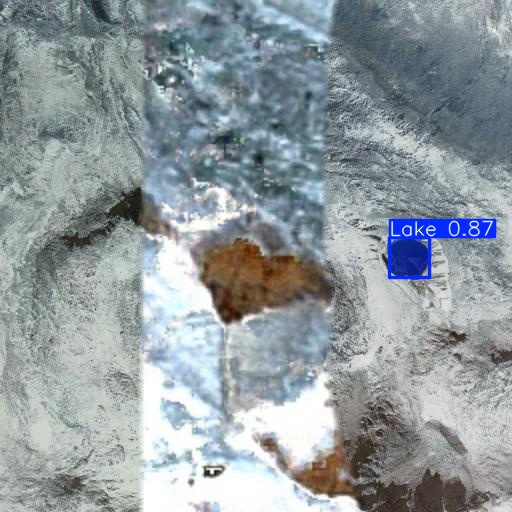

Debris Cover_1712.jpg


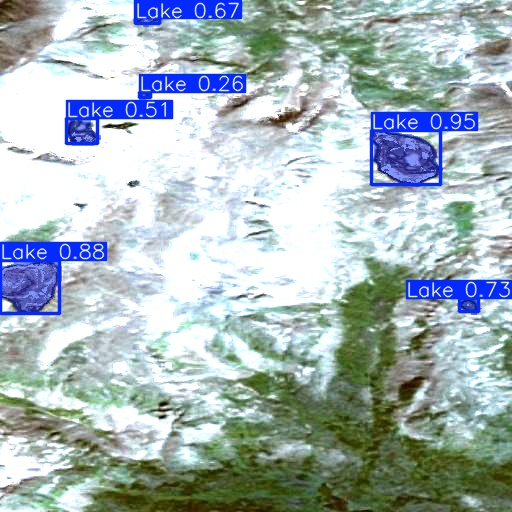

Moraine Dammed_1395.jpg


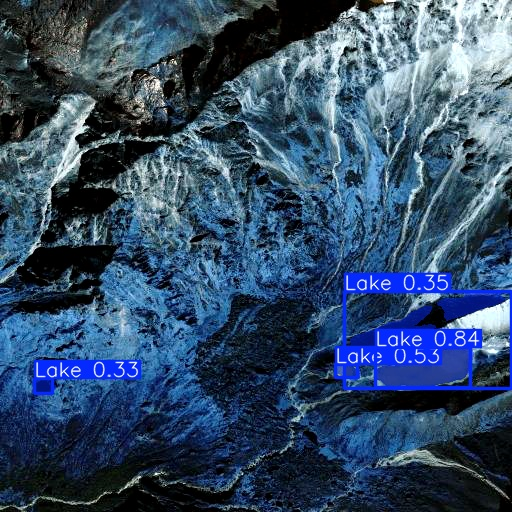

Snow Cover_884.jpg


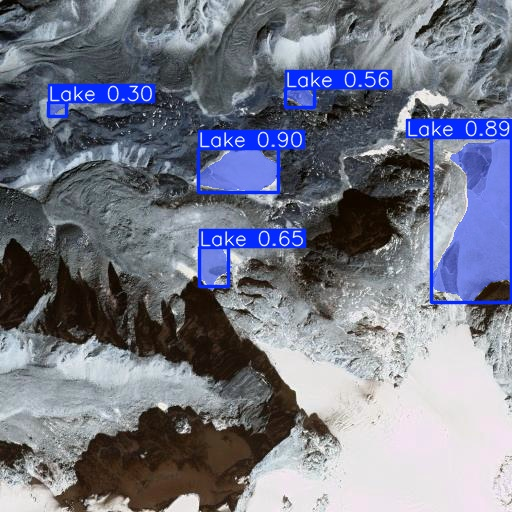

Snow Cover_413.jpg


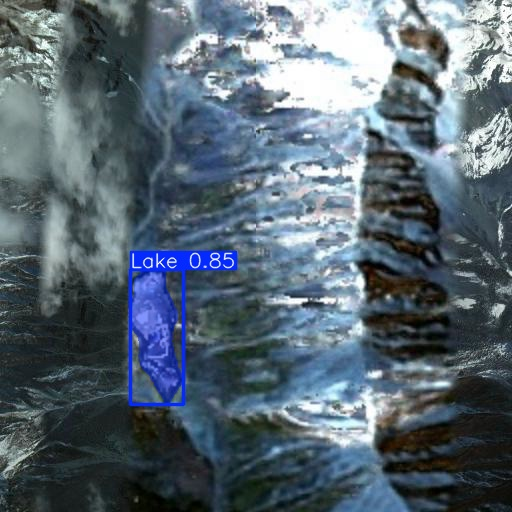

Snow Cover_303.jpg


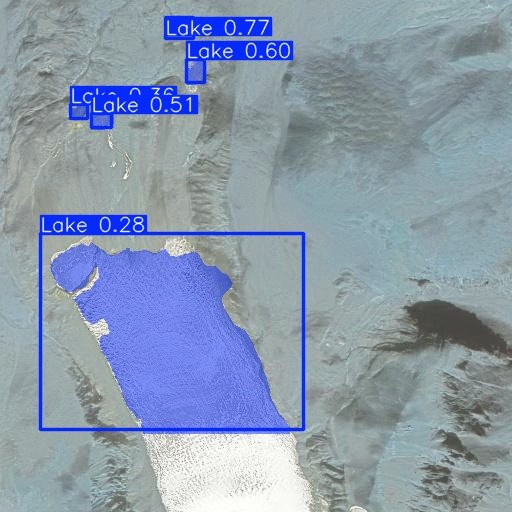

Debris Cover_1797.jpg


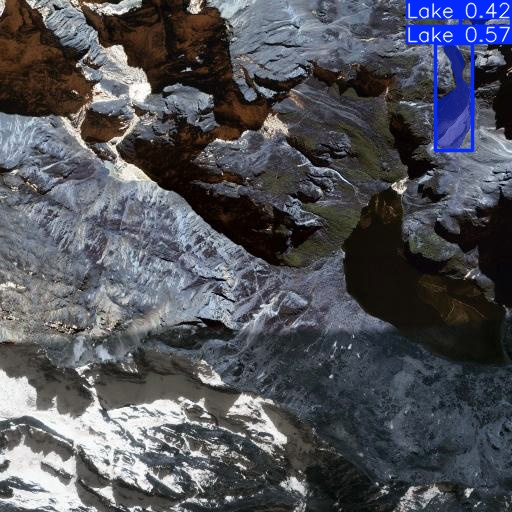

Moraine Dammed_1411.jpg


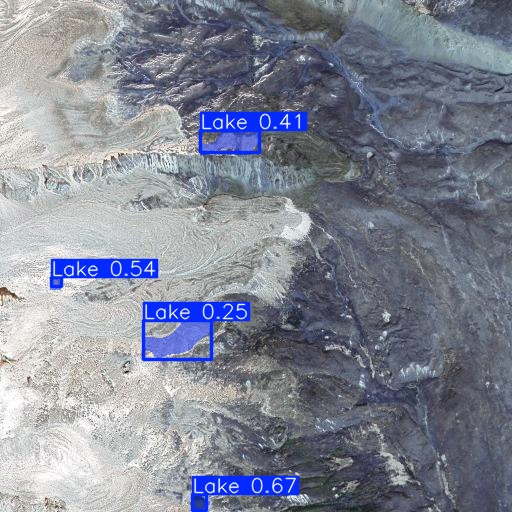

Debris Cover_667.jpg


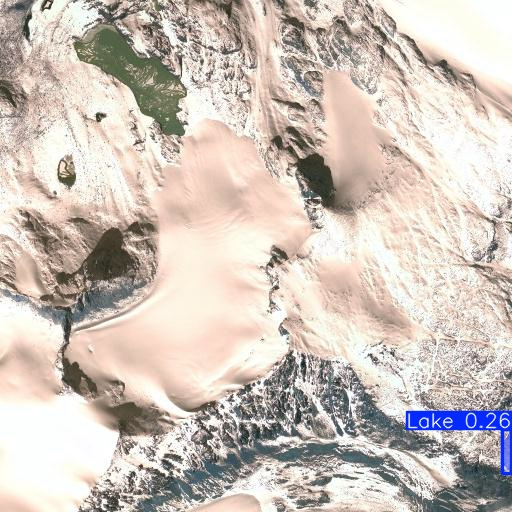

Moraine Dammed_1575.jpg


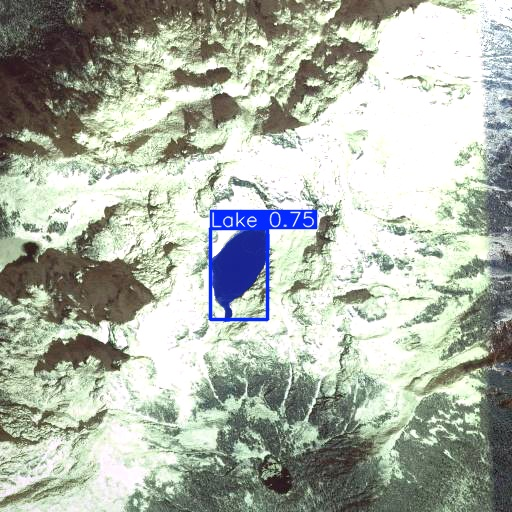

In [38]:
from IPython.display import Image, display
import os
import random

pred_folder = "/content/runs/segment/predict"

files = os.listdir(pred_folder)

for f in random.sample(files, 10):
    print(f)
    display(Image(os.path.join(pred_folder, f)))

In [40]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt")

metrics = model.val(
    data="/content/lake_dataset/lake.yaml",
    split="test"
)

print("mAP50 =", metrics.seg.map50 * 100)
print("mAP50-95 =", metrics.seg.map * 100)
print("Precision =", metrics.seg.mp * 100)
print("Recall =", metrics.seg.mr * 100)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2785.6±889.6 MB/s, size: 495.3 KB)
val: Scanning /content/lake_dataset/test/labels.cache... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 51.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.2it/s 11.3s
                   all        220        519      0.778      0.719      0.781      0.509      0.814      0.708      0.788      0.478
Speed: 3.6ms preprocess, 30.6ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/segment/val-5
mAP50 = 78.81858326729575
mAP50-95 = 47.78439351787657
Precision = 81.40298987900117
Recall = 70.84508424658559


In [45]:
!find /content -name best.pt

/content/runs/segment/LakeRuns/YOLO11L_LAKE-2/weights/best.pt
/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt


In [47]:
from google.colab import files

files.download("/content/runs/segment/LakeRuns/YOLO11L_LAKE-2/weights/best.pt")
files.download("/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
!find /content -name last.pt

/content/runs/segment/LakeRuns/YOLO11L_LAKE-2/weights/last.pt
/content/runs/segment/LakeRuns/Quick_Test/weights/last.pt


In [49]:
from google.colab import files

files.download(
    "/content/runs/segment/LakeRuns/Quick_Test/weights/last.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
%%writefile train.py

from ultralytics import YOLO

model = YOLO("yolo11m-seg.pt")

model.train(
    data="lake.yaml",
    epochs=50,
    imgsz=640,
    batch=4,
    optimizer="AdamW"
)

Writing train.py


In [51]:
from google.colab import files
files.download("train.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
%%writefile inference.py

from ultralytics import YOLO

model = YOLO("best.pt")

results = model.predict(
    source="images",
    save=True,
    conf=0.25
)

Writing inference.py


In [53]:
from google.colab import files
files.download("inference.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
%%writefile model_architecture.py

from ultralytics import YOLO

model = YOLO("yolo11m-seg.pt")

print(model.model)

Writing model_architecture.py


In [55]:
from google.colab import files
files.download("model_architecture.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
%%writefile utils.py

import cv2

def read_image(path):
    return cv2.imread(path)

def save_image(img, path):
    cv2.imwrite(path, img)

Writing utils.py


In [57]:
from google.colab import files
files.download("utils.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
%%writefile requirements.txt

ultralytics==8.4.71
torch
torchvision
opencv-python
numpy
matplotlib
pyyaml
scipy
pillow

Writing requirements.txt


In [59]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
%%writefile README.md

# GLOF Lake Detection

Automated Detection of Glacial Lakes using YOLO11 Segmentation.

## Files

best.pt
last.pt
train.py
inference.py
model_architecture.py
utils.py

## Training

python train.py

## Inference

python inference.py

Writing README.md


In [61]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
%%writefile Technical_Report.txt

AUTOMATED DETECTION OF GLACIAL LAKES

Objective:
Detect glacial lakes from satellite imagery.

Model:
YOLO11m-Seg

Dataset:
Moraine Dammed
Snow Cover
Terrain Shadow
Debris Cover
Varying Turbidity

Training:
Epochs: 50
Image Size: 640
Optimizer: AdamW

Conclusion:
The model successfully segments glacial lakes from satellite imagery.

Writing Technical_Report.txt


In [63]:
from google.colab import files
files.download("Technical_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
%%writefile Evaluation_Report.txt

mAP50:
mAP50-95:
Precision:
Recall:

Dataset:
Train:
Validation:
Test:

Writing Evaluation_Report.txt


In [65]:
from google.colab import files
files.download("Evaluation_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt"
)

metrics = model.val(
    data="/content/lake_dataset/lake.yaml",
    split="test"
)

print("mAP50 =", metrics.seg.map50 * 100)
print("mAP50-95 =", metrics.seg.map * 100)
print("Precision =", metrics.seg.mp * 100)
print("Recall =", metrics.seg.mr * 100)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3213.4±1260.7 MB/s, size: 465.1 KB)
val: Scanning /content/lake_dataset/test/labels.cache... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 48.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.1it/s 12.6s
                   all        220        519      0.778      0.719      0.781      0.509      0.814      0.708      0.788      0.478
Speed: 4.2ms preprocess, 30.9ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/runs/segment/val-6
mAP50 = 78.81858326729575
mAP50-95 = 47.78439351787657
Precision = 81.40298987900117
Recall = 70.84508424658559


In [67]:
report = f"""
Evaluation Report

Model: YOLO11m-Seg

mAP50: {metrics.seg.map50*100:.2f}

mAP50-95: {metrics.seg.map*100:.2f}

Precision: {metrics.seg.mp*100:.2f}

Recall: {metrics.seg.mr*100:.2f}

Dataset:
Train: 1749
Validation: 218
Test: 220
"""

with open("Evaluation_Report.txt", "w") as f:
    f.write(report)

print(report)


Evaluation Report

Model: YOLO11m-Seg

mAP50: 78.82

mAP50-95: 47.78

Precision: 81.40

Recall: 70.85

Dataset:
Train: 1749
Validation: 218
Test: 220



In [68]:
from google.colab import files

files.download("Evaluation_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/segment/LakeRuns/Quick_Test/weights/best.pt"
)

model.predict(
    source="/content/lake_dataset/test/images",
    save=True,
    conf=0.25
)


image 1/220 /content/lake_dataset/test/images/Debris Cover_1077.png: 640x640 (no detections), 50.1ms
image 2/220 /content/lake_dataset/test/images/Debris Cover_1085.png: 640x640 1 Lake, 49.9ms
image 3/220 /content/lake_dataset/test/images/Debris Cover_1283.png: 640x640 4 Lakes, 30.9ms
image 4/220 /content/lake_dataset/test/images/Debris Cover_1450.png: 640x640 8 Lakes, 30.9ms
image 5/220 /content/lake_dataset/test/images/Debris Cover_1467.png: 640x640 2 Lakes, 29.7ms
image 6/220 /content/lake_dataset/test/images/Debris Cover_1505.png: 640x640 2 Lakes, 29.6ms
image 7/220 /content/lake_dataset/test/images/Debris Cover_1670.png: 640x640 4 Lakes, 25.0ms
image 8/220 /content/lake_dataset/test/images/Debris Cover_1676.png: 640x640 1 Lake, 25.1ms
image 9/220 /content/lake_dataset/test/images/Debris Cover_1712.png: 640x640 6 Lakes, 24.8ms
image 10/220 /content/lake_dataset/test/images/Debris Cover_1745.png: 640x640 1 Lake, 25.7ms
image 11/220 /content/lake_dataset/test/images/Debris Cover_179

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Lake'}
 obb: None
 orig_img: array([[[255, 254, 253],
         [255, 251, 250],
         [255, 254, 253],
         ...,
         [146, 154, 165],
         [131, 141, 153],
         [104, 114, 126]],
 
        [[251, 247, 246],
         [252, 248, 247],
         [255, 254, 253],
         ...,
         [168, 177, 186],
         [149, 157, 168],
         [118, 128, 140]],
 
        [[255, 253, 253],
         [255, 251, 251],
         [255, 254, 253],
         ...,
         [181, 188, 198],
         [154, 163, 172],
         [119, 129, 139]],
 
        ...,
 
        [[ 31,  37,  27],
         [ 27,  33,  23],
         [ 24,  30,  20],
         ...,
         [173, 159, 132],
         [142, 128, 100],
         [111,  97,  68]],
 
        [[ 40,  46,  36],
         [ 35,  41,  31],
         [ 31,  37,  27],
         ...,
         [166, 152, 

In [70]:
!zip -r Validation_Predictions.zip /content/runs/segment/predict

  adding: content/runs/segment/predict/ (stored 0%)
  adding: content/runs/segment/predict/Moraine Dammed_55.jpg (deflated 5%)
  adding: content/runs/segment/predict/Moraine Dammed_2275.jpg (deflated 5%)
  adding: content/runs/segment/predict/Varying Turbidity_1354.jpg (deflated 2%)
  adding: content/runs/segment/predict/Snow Cover_952.jpg (deflated 6%)
  adding: content/runs/segment/predict/Moraine Dammed_404.jpg (deflated 3%)
  adding: content/runs/segment/predict/Moraine Dammed_1024.jpg (deflated 4%)
  adding: content/runs/segment/predict/Moraine Dammed_2256.jpg (deflated 6%)
  adding: content/runs/segment/predict/Moraine Dammed_1150.jpg (deflated 2%)
  adding: content/runs/segment/predict/Terrain Shadow_2073.jpg (deflated 5%)
  adding: content/runs/segment/predict/Snow Cover_391.jpg (deflated 1%)
  adding: content/runs/segment/predict/Snow Cover_902.jpg (deflated 4%)
  adding: content/runs/segment/predict/Snow Cover_2337.jpg (deflated 6%)
  adding: content/runs/segment/predict/Snow

In [71]:
from google.colab import files

files.download("Validation_Predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>